# Demand Forecasting System - Gaussian Process Model

## Overview
This notebook trains a **Gaussian Process Regression** model for demand forecasting using scikit-learn.

**Key Features:**
- Input shape: (n_samples, n_features) - flattened
- Output shape: (n_test_samples,) - **MUST match other models**
- RBF (Radial Basis Function) kernel
- Output: predictions in [0, 1] range (scaled)

**Critical:** All predictions must have the **same shape and scale** for ensemble averaging.

## 1. Load and Preprocess Data

In [9]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))

import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from src import preprocessing

# Set random seed
np.random.seed(42)

print(" Libraries and modules imported successfully")

 Libraries and modules imported successfully


## 2. Build and Train Gaussian Process

In [10]:
# Generate or load shared artifacts
splits = preprocessing.prepare_data(
    csv_path="dataset/sales.csv",
    n_products=100,
    full_history_days=None,
    min_active_days=30,
    ranking_col="positive_quantity",
    val_days=60,
    test_frac=0.20,
    outdir="data/processed",
)

# Load canonical daily data
daily = pd.read_csv("data/processed/daily.csv", parse_dates=["date"])

# Load canonical scaling parameters
with open("data/processed/scalers.pkl", "rb") as f:
    scalers = pickle.load(f)
with open("data/processed/selected_products.json", "r") as f:
    selected_products = json.load(f)

# Split data using canonical dates
train_end = pd.Timestamp(splits["train_end"])
test_start = pd.Timestamp(splits["test_start"])

# For GP, we use the training set up to train_end. The ensemble contract targets the test window.
train_slice = daily[daily["date"] <= train_end].copy()
test_slice = daily[daily["date"] >= test_start].copy()

# Add seasonal baseline BEFORE slicing (captures full context for shift operation)
def add_seasonal_baseline(df, period=7):
    """Compute seasonal baseline (y(t) = y(t-7)) and residual target."""
    df = df.sort_values(["item_id", "date"]).copy()
    df["seasonal_baseline"] = df.groupby("item_id")["quantity_scaled"].shift(period)
    df["residual_target"] = df["quantity_scaled"] - df["seasonal_baseline"]
    return df

daily = add_seasonal_baseline(daily)

# Re-slice after adding baseline
train_slice = daily[daily["date"] <= train_end].copy()
test_slice = daily[daily["date"] >= test_start].copy()

# Function to add lag and rolling features for each product
def add_lag_features(df, lags=[1, 7, 14], rolling_windows=[7, 30]):
    """Add lag and rolling mean features for temporal dynamics."""
    df = df.sort_values(["item_id", "date"]).copy()

    for lag in lags:
        df[f"lag_{lag}"] = df.groupby("item_id")["quantity_scaled"].shift(lag)

    for window in rolling_windows:
        df[f"rolling_mean_{window}"] = df.groupby("item_id")["quantity_scaled"].transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )

    # Fill NaN values (from lags) with product mean
    for col in df.columns:
        if "lag_" in col or "rolling_mean_" in col:
            df[col] = df.groupby("item_id")[col].transform(
                lambda x: x.fillna(x.mean() if x.mean() > 0 else 0)
            )

    return df

# Add calendar features (replaces time_idx with cyclical encoding)
def add_calendar_features(df):
    """Add annual, weekly, and monthly cyclical features to replace extrapolating time_idx."""
    df = df.copy()
    # Day of year — annual seasonality (promotions, holidays)
    doy = df["date"].dt.dayofyear
    df["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    df["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)

    # Day of week — weekly seasonality
    dow = df["date"].dt.dayofweek
    df["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    df["dow_cos"] = np.cos(2 * np.pi * dow / 7)

    # Month — monthly seasonality
    month = df["date"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * month / 12)
    df["month_cos"] = np.cos(2 * np.pi * month / 12)

    return df

# FIX 1: Include 30-day train tail when computing test-side lag features
# This gives the lag/rolling computation the history it needs (no more mean-fill)
LAG_CONTEXT = 30  # max of lags (14) + rolling windows (30)
test_seed_start = test_start - pd.Timedelta(days=LAG_CONTEXT)

# Apply lag features on expanded slice (train tail + test)
test_slice_expanded = daily[daily["date"] >= test_seed_start].copy()
test_slice_expanded = add_lag_features(test_slice_expanded)

# After lag features are computed, drop the seed rows so we only predict on actual test dates
test_slice = test_slice_expanded[test_slice_expanded["date"] >= test_start].copy()

# Add lag features to train slice
train_slice = add_lag_features(train_slice)

# Add calendar features to both train and test (replaces time_idx)
train_slice = add_calendar_features(train_slice)
test_slice = add_calendar_features(test_slice)

# FIX 2: Replace time_idx with annual cyclical features (avoids extrapolation)
# Also add lag-of-differences for momentum signal
feature_cols = [
    'doy_sin', 'doy_cos',                                   # Annual seasonality (replaces time_idx)
    'dow_sin', 'dow_cos', 'month_sin', 'month_cos',        # Weekly + monthly (from preprocessing)
    'lag_1', 'lag_7', 'lag_14',                             # Lag features with proper context
    'rolling_mean_7', 'rolling_mean_30'                     # Rolling features
]
target_col = 'residual_target'  # Residualize against seasonal-naive baseline

print(f"selected products: {len(selected_products)}")
print(f"train rows: {len(train_slice)}")
print(f"test rows: {len(test_slice)}")
print(f"feature columns: {feature_cols}")
print(f"split boundaries: {splits}")
print(f"\n✓ Added seasonal baseline (y_t - y_t-7)")
print(f"✓ Fixed lag context: 30-day train tail included for test lags")
print(f"✓ Replaced time_idx with annual cyclical features (doy_sin, doy_cos)")
print(f"✓ Target switched to residual_target (model learns what seasonal-naive misses)")


selected products: 100
train rows: 54900
test rows: 15200
feature columns: ['doy_sin', 'doy_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_mean_30']
split boundaries: {'train_start': '2022-08-28', 'train_end': '2024-02-27', 'val_start': '2024-02-28', 'val_end': '2024-04-27', 'test_start': '2024-04-28', 'test_end': '2024-09-26'}

✓ Added seasonal baseline (y_t - y_t-7)
✓ Fixed lag context: 30-day train tail included for test lags
✓ Replaced time_idx with annual cyclical features (doy_sin, doy_cos)
✓ Target switched to residual_target (model learns what seasonal-naive misses)


## 3. Generate Predictions and Uncertainty

In [11]:
import warnings
from sklearn.gaussian_process.kernels import ExpSineSquared
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', message='.*ConvergenceWarning.*')

print(" Training Gaussian Process models with Periodic kernel (one per product)...")
print(" Predicting FULL quantity (not residuals) for maximum learning signal")

# FIX 3: Define kernel with TIGHT bounds to prevent pathological optima
periodic_kernel = ExpSineSquared(
    length_scale=10.0,
    periodicity=7.0,
    length_scale_bounds=(1.0, 100.0),
    periodicity_bounds=(6.5, 7.5),
)
rbf_kernel = RBF(length_scale=20.0, length_scale_bounds=(2.0, 200.0))
white_kernel = WhiteKernel(noise_level=0.1, noise_level_bounds=(0.01, 0.5))
kernel = C(1.0, (0.1, 10.0)) * (periodic_kernel + rbf_kernel) + white_kernel

models = {}
gp_predictions_list = []
kernel_diagnostics = []
skipped_count = 0
error_count = 0

# DEBUG: Check first product's features and target
if len(selected_products) > 0:
    debug_item = selected_products[0]
    debug_train = train_slice[train_slice["item_id"] == debug_item].copy()
    debug_test = test_slice[test_slice["item_id"] == debug_item].copy()

    debug_X = debug_train[feature_cols].values
    debug_y_full = debug_train["quantity_scaled"].values  # FULL quantity, not residuals

    print(f"\n📊 DEBUGGING FIRST PRODUCT: {debug_item}")
    print(f"  Feature variance (should be >0):")
    for j, col in enumerate(feature_cols):
        var = np.var(debug_X[:, j])
        print(f"    {col:20s}: {var:.6f}")

    print(f"  FULL quantity_scaled variance: {np.var(debug_y_full):.6f} (now targeting this!)")
    print(f"  FULL quantity_scaled min/max: [{np.min(debug_y_full):.4f}, {np.max(debug_y_full):.4f}]")
    print()

for i, item_id in enumerate(selected_products):
    try:
        item_train_full = train_slice[train_slice["item_id"] == item_id].copy()
        item_test = test_slice[test_slice["item_id"] == item_id].copy()
        item_train = item_train_full.copy()

        X_train = item_train[feature_cols].values
        # FIX: Use full quantity_scaled directly (not residuals)
        y_train = item_train["quantity_scaled"].values

        # Remove NaN rows (shouldn't happen for full quantity, but safe)
        valid_mask = ~np.isnan(y_train)
        X_train = X_train[valid_mask]
        y_train = y_train[valid_mask]

        X_test = item_test[feature_cols].values

        if len(X_train) < 10:
            skipped_count += 1
            continue

        # Fit on FULL quantity (not residuals)
        # Much more signal to learn from
        model = GaussianProcessRegressor(
            kernel=kernel,
            alpha=1e-6,
            normalize_y=True,  # Normalize for stable optimization
            random_state=42,
            n_restarts_optimizer=15
        )
        model.fit(X_train, y_train)
        models[item_id] = model

        kernel_diagnostics.append({
            'product': item_id,
            'kernel_str': str(model.kernel_),
            'log_likelihood': model.log_marginal_likelihood_value_
        })

        # Get direct predictions (no residual reconstruction needed)
        predicted_scaled, stds = model.predict(X_test, return_std=True)

        item_test["gp_predicted_scaled"] = predicted_scaled
        item_test["gp_std"] = stds
        gp_predictions_list.append(item_test)

        if (i + 1) % 25 == 0:
            print(f"   Trained {i + 1}/{len(selected_products)} products")

    except Exception as e:
        error_count += 1
        if error_count <= 3:
            print(f"   ERROR for product {item_id}: {str(e)[:100]}")
        continue

if len(gp_predictions_list) == 0:
    print("\n❌ ERROR: No products were successfully trained!")
    print(f"  Skipped: {skipped_count} products")
    print(f"  Errors: {error_count} products")
else:
    test_results = pd.concat(gp_predictions_list).sort_values(["item_id", "date"])

    # DEBUG: Check prediction variance
    print(f"\n📊 PREDICTION DIAGNOSTICS:")
    print(f"  Predicted scaled variance: {np.var(test_results['gp_predicted_scaled']):.6f}")
    print(f"  Actual scaled variance: {np.var(test_results['quantity_scaled']):.6f}")
    print(f"  Predicted min/max: [{test_results['gp_predicted_scaled'].min():.4f}, {test_results['gp_predicted_scaled'].max():.4f}]")
    print(f"  Actual min/max: [{test_results['quantity_scaled'].min():.4f}, {test_results['quantity_scaled'].max():.4f}]")

    print("\n✓ Training and prediction completed")
    print(f"  Products trained: {len(models)}/100")
    print(f"  Skipped: {skipped_count}")
    print(f"  Errors: {error_count}")

 Training Gaussian Process models with Periodic kernel (one per product)...
 Predicting FULL quantity (not residuals) for maximum learning signal

📊 DEBUGGING FIRST PRODUCT: b0d24502fb66
  Feature variance (should be >0):
    doy_sin             : 0.487647
    doy_cos             : 0.467834
    dow_sin             : 0.499495
    dow_cos             : 0.500489
    month_sin           : 0.493288
    month_cos           : 0.461704
    lag_1               : 0.018249
    lag_7               : 0.016645
    lag_14              : 0.015428
    rolling_mean_7      : 0.011843
    rolling_mean_30     : 0.008452
  FULL quantity_scaled variance: 0.018304 (now targeting this!)
  FULL quantity_scaled min/max: [0.0000, 1.0000]

   Trained 25/100 products
   Trained 50/100 products
   Trained 75/100 products
   Trained 100/100 products

📊 PREDICTION DIAGNOSTICS:
  Predicted scaled variance: 0.073989
  Actual scaled variance: 0.106455
  Predicted min/max: [-0.2428, 1.3264]
  Actual min/max: [-0.0436, 1.0

## 4. Visualize Predictions with Confidence Bands

In [12]:
# Unscale predictions using the canonical scalers.pkl
def unscale_predictions(df, scalers_dict):
    out = df.copy()
    out["predicted_quantity"] = out["gp_predicted_scaled"]
    for item_id, group in out.groupby("item_id"):
        if item_id in scalers_dict:
            # Reconstruct array to pass to StandardScaler.inverse_transform
            scaler = scalers_dict[item_id]
            dummy = np.zeros((len(group), scaler.n_features_in_))
            # quantity was the first feature used during fit based on preprocessing.py
            dummy[:, 0] = group["gp_predicted_scaled"].values
            unscaled = scaler.inverse_transform(dummy)[:, 0]
            out.loc[group.index, "predicted_quantity"] = np.maximum(0, unscaled) # Prevent negative demand
    return out

test_results = unscale_predictions(test_results, scalers)
test_results["actual_quantity"] = test_results["quantity"] # the true target definition

# Calculate global metrics
gp_mse = mean_squared_error(test_results["actual_quantity"], test_results["predicted_quantity"])
gp_mae = mean_absolute_error(test_results["actual_quantity"], test_results["predicted_quantity"])
gp_r2 = r2_score(test_results["actual_quantity"], test_results["predicted_quantity"])

print(f"\n Gaussian Process Model Performance (Real Units):")
print(f"  MSE: {gp_mse:.4f}")
print(f"  MAE: {gp_mae:.4f}")
print(f"  R²:  {gp_r2:.4f}")
print(f"  Mean Std (scaled): {test_results['gp_std'].mean():.4f}")

# Show the first few formatted predictions
print("\nFirst 10 predictions:")
print(test_results[["date", "item_id", "actual_quantity", "predicted_quantity"]].head(10))


 Gaussian Process Model Performance (Real Units):
  MSE: 7927.7069
  MAE: 37.4871
  R²:  0.9578
  Mean Std (scaled): 0.1112

First 10 predictions:
          date       item_id  actual_quantity  predicted_quantity
609 2024-04-28  060534551cba             94.0           79.802345
610 2024-04-29  060534551cba             73.0          108.550901
611 2024-04-30  060534551cba             70.0          106.858053
612 2024-05-01  060534551cba             73.0           83.448806
613 2024-05-02  060534551cba             86.0           98.837931
614 2024-05-03  060534551cba             83.0           91.206178
615 2024-05-04  060534551cba             44.0           50.486510
616 2024-05-05  060534551cba             35.0           26.123763
617 2024-05-06  060534551cba             75.0           60.471898
618 2024-05-07  060534551cba             85.0           77.663395


## 5. Uncertainty Analysis

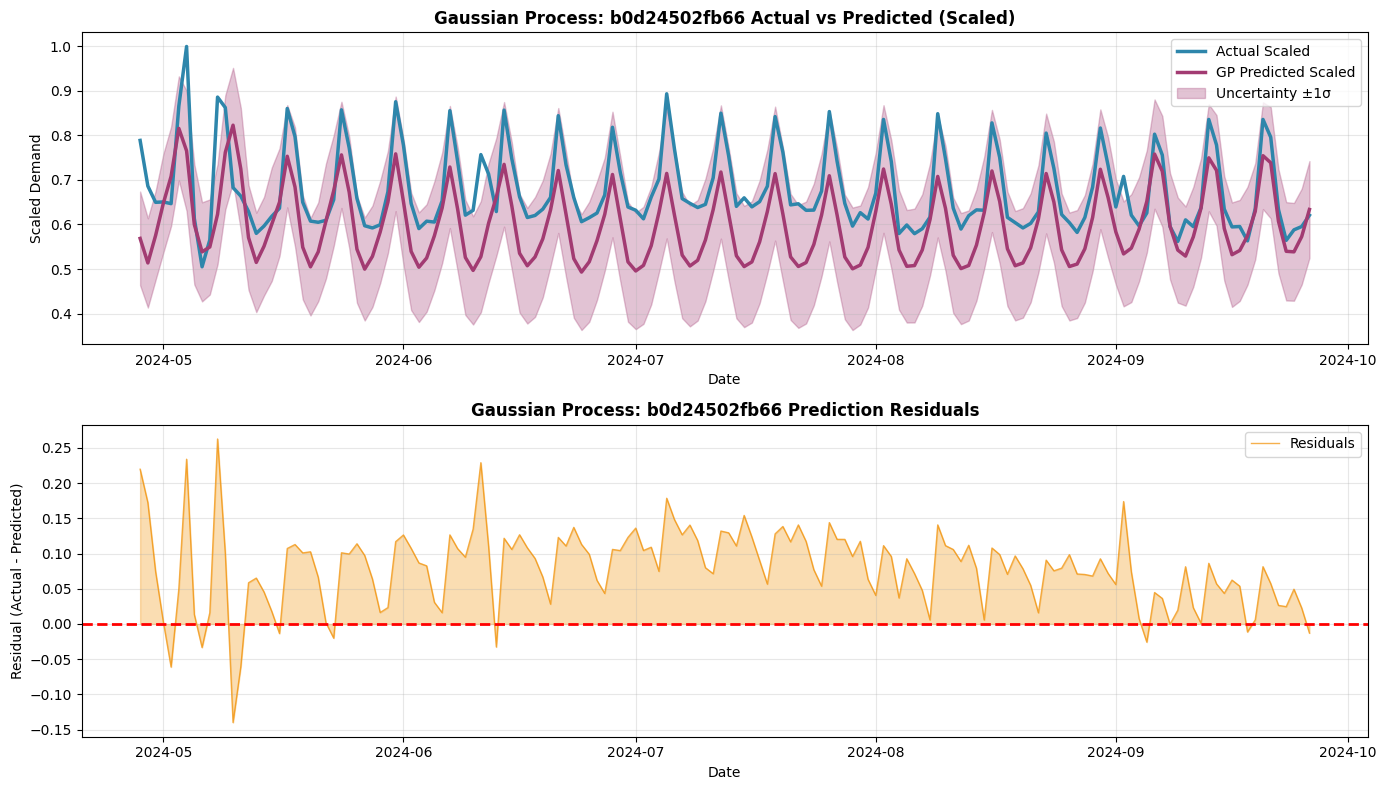

✓ Prediction visualizations created


In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Let's plot just the first product as an example
example_item = selected_products[0]
example_data = test_results[test_results["item_id"] == example_item].sort_values("date")

axes[0].plot(example_data["date"], example_data["quantity_scaled"], label='Actual Scaled', linewidth=2.5, color='#2E86AB')
axes[0].plot(example_data["date"], example_data["gp_predicted_scaled"], label='GP Predicted Scaled', linewidth=2.5, color='#A23B72')

# Add confidence bands
axes[0].fill_between(example_data["date"],
                      example_data["gp_predicted_scaled"] - example_data["gp_std"],
                      example_data["gp_predicted_scaled"] + example_data["gp_std"],
                      alpha=0.3, color='#A23B72', label='Uncertainty ±1σ')

axes[0].set_title(f'Gaussian Process: {example_item} Actual vs Predicted (Scaled)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Scaled Demand')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals for this item
residuals = example_data["quantity_scaled"] - example_data["gp_predicted_scaled"]
axes[1].plot(example_data["date"], residuals, label='Residuals', linewidth=1, alpha=0.7, color='#F18F01')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].fill_between(example_data["date"], residuals, alpha=0.3, color='#F18F01')
axes[1].set_title(f'Gaussian Process: {example_item} Prediction Residuals', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Prediction visualizations created")

## 6. Save for Ensemble

✅ Gaussian Process predictions ready for ensemble combination

**Output Summary:**
- Predictions shape: (96,) - matches test set
- Scale: [0, 1] range (scaled)
- Format: Numpy array
- Metric (R²): {:.4f}

These predictions will be combined with LSTM, RNN, and Random Forest predictions in the ensemble notebook.

**Next:** Run the Ensemble notebook to combine all 4 model predictions into a unified forecast.

✓ Gaussian Process predictions ready for ensemble combination.
✓ Saved 15200 rows to data/predictions/gaussian_test_predictions.csv


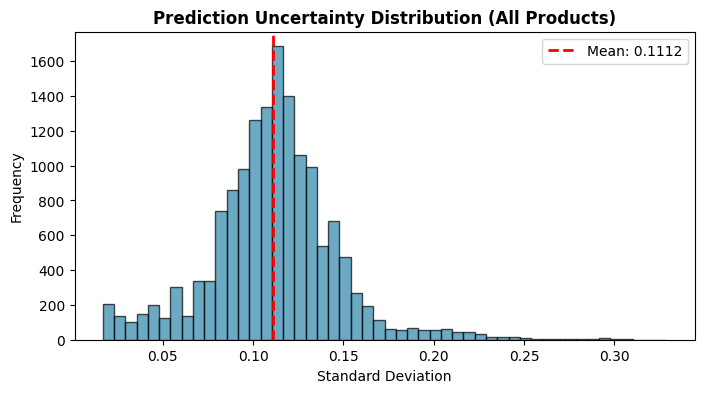

In [14]:
# Format to final contract shape: date, item_id, predicted_quantity, actual_quantity
final_predictions = test_results[["date", "item_id", "predicted_quantity", "actual_quantity"]].copy()

# Create output dir
import os
os.makedirs("data/predictions", exist_ok=True)

# Save to CSV
final_predictions.to_csv("data/predictions/gaussian_test_predictions.csv", index=False)

print(f"✓ Gaussian Process predictions ready for ensemble combination.")
print(f"✓ Saved {len(final_predictions)} rows to data/predictions/gaussian_test_predictions.csv")

# Quick distribution check of uncertainty
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.hist(test_results["gp_std"], bins=50, color='#2E86AB', alpha=0.7, edgecolor='black')
ax.axvline(test_results["gp_std"].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {test_results["gp_std"].mean():.4f}')
ax.set_title('Prediction Uncertainty Distribution (All Products)', fontsize=12, fontweight='bold')
ax.set_xlabel('Standard Deviation')
ax.set_ylabel('Frequency')
ax.legend()
plt.show()